<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
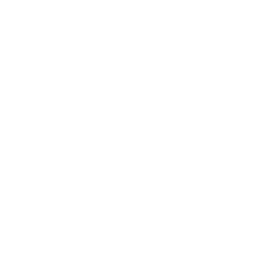
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Building Energy Efficiency Clustering</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energy / Sustainability Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Este exemplo prático agrupa uma carteira de edifícios comerciais por cinco métricas de eficiência energética — Intensidade de Uso de Energia (EUI), razão de eficiência do HVAC, resistência térmica do envelope, densidade de potência de iluminação e percentual de compensação renovável — para revelar níveis de desempenho distintos para direcionamento de incentivos de concessionárias. A análise usa **PROC FASTCLUS** com `REPLACE=FULL` (substituição completa de sementes) e compara as soluções k=3, 4, 5 e 6 quanto ao R-quadrado geral, à estatística pseudo-F e ao tamanho mínimo de agrupamento. A solução k=4 é então perfilada em detalhe e cada agrupamento é mapeado para um nível de eficiência acionável. Como este ambiente roda sem licença, a demonstração é limitada a uma amostra de 100 edifícios; o mesmo programa escala sem alterações para uma carteira completa.


## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | Métricas anuais de eficiência energética por edifício (sintético) | 100 |



---

In [1]:
/* --------------------------------------------------------
   Gera métricas sintéticas de energia de edifícios
   Indicadores de eficiência de edifícios comerciais
   -------------------------------------------------------- */
DADOS work.building_metrics;
    CHAMAR streaminit(42);
    VETOR btypes[5] $15 _temporary_ ('ESCRITORIO' 'VAREJO' 'ARMAZEM' 'HOSPITAL' 'ESCOLA');
    VETOR regions[4] $12 _temporary_ ('NORDESTE' 'SUDESTE' 'CENTRO-OESTE' 'OESTE');
    FAZER building_id = 1 ATÉ 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        building_type = btypes[type_idx];
        reg_idx = int(rand('uniform') * 4) + 1;
        climate_region = regions[reg_idx];

        /* Intensidade de Uso de Energia (kBtu/pe2/ano) */
        eui = round(rand('normal', 85, 35), 0.1);
        SE eui < 15 ENTÃO eui = 15;
        SE eui > 250 ENTÃO eui = 250;

        /* Razao de eficiencia do HVAC (equivalente COP) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        SE hvac_efficiency < 1.0 ENTÃO hvac_efficiency = 1.0;
        SE hvac_efficiency > 6.0 ENTÃO hvac_efficiency = 6.0;

        /* Resistencia termica do envelope (valor R) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        SE envelope_r_value < 5 ENTÃO envelope_r_value = 5;
        SE envelope_r_value > 40 ENTÃO envelope_r_value = 40;

        /* Densidade de potencia de iluminacao (W/pe2) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        SE lighting_wpf < 0.3 ENTÃO lighting_wpf = 0.3;
        SE lighting_wpf > 2.5 ENTÃO lighting_wpf = 2.5;

        /* Percentual de compensacao com energia renovavel */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        SE renewable_pct > 80 ENTÃO renewable_pct = 80;

        /* Idade do edificio em anos */
        building_age = int(rand('uniform') * 80) + 1;

        /* Area do piso (milhares de pe2) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        SE floor_area_ksf > 500 ENTÃO floor_area_ksf = 500;

        SAÍDA;
    FIM;
    REMOVER type_idx reg_idx;
EXECUTAR;



NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.54 seconds
  cpu   1.54 seconds


---

In [2]:
/* --------------------------------------------------------
   Distribuicoes basais das metricas de energia por tipo de edificio
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.building_metrics n mean std;
    CLASSE building_type;
    VARIÁVEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    RÓTULO building_type="Tipo de Edificio"
          eui="EUI (kBtu/pe2/ano)"
          hvac_efficiency="Eficiencia do HVAC (COP)"
          envelope_r_value="Envelope (valor R)"
          lighting_wpf="Iluminacao (W/pe2)"
          renewable_pct="Percentual Renovavel (%)";
    TÍTULO "Metricas de Energia por Tipo de Edificio";
EXECUTAR;


                                        Metricas de Energia por Tipo de Edificio                                        

                                                  The MEANS Procedure

                                       Analysis Variable : eui EUI (kBtu/pe2/ano)

        Tipo de Edificio          N Obs           Mean        Std Dev
        -------------------------------------------------------------
        ARMAZEM                      20     90.8900000     33.5993249
        ESCOLA                       19     89.7000000     39.0498542
        ESCRITORIO                   20     73.0550000     40.3950163
        HOSPITAL                     25     87.9040000     35.2632892
        VAREJO                       16     79.7312500     42.6818106
        -------------------------------------------------------------

                              Analysis Variable : hvac_efficiency Eficiencia do HVAC (COP)

        Tipo de Edificio          N Obs           Mean        Std Dev
 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                        Metricas de Energia por Tipo de Edificio                                        




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


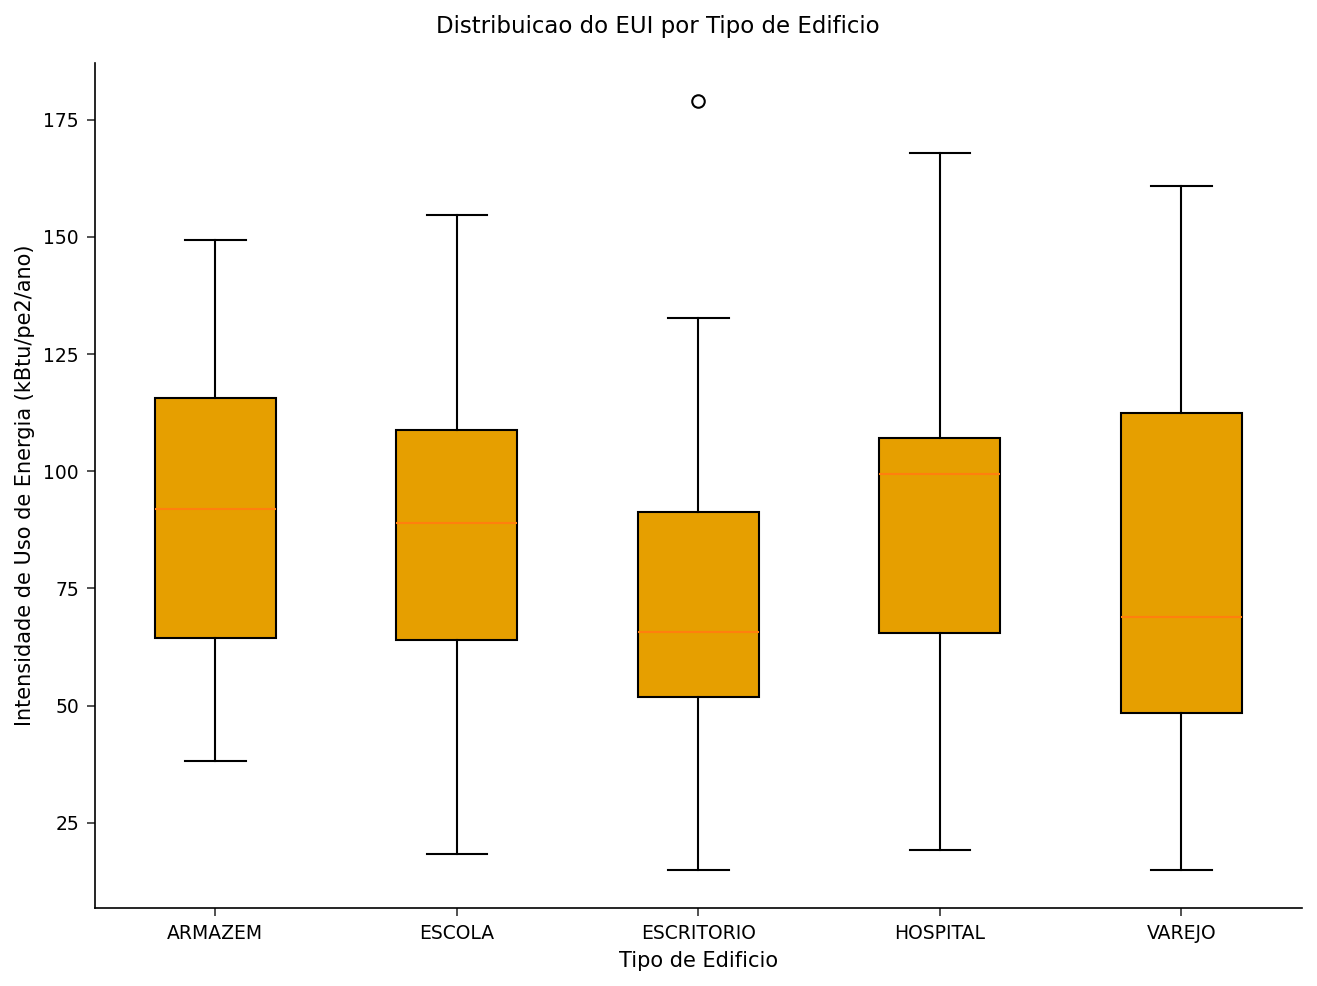

In [3]:
/* --------------------------------------------------------
   Distribuicao do EUI por tipo de edificio
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS RÓTULO="Tipo de Edificio";
    YAXIS RÓTULO="Intensidade de Uso de Energia (kBtu/pe2/ano)";
    TÍTULO "Distribuicao do EUI por Tipo de Edificio";
EXECUTAR;


---

In [4]:
/* --------------------------------------------------------
   Padroniza as metricas de eficiencia
   -------------------------------------------------------- */
PROCEDIMENTO STANDARD DADOS=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    VARIÁVEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
EXECUTAR;



NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   Agrupamento k-means: k=3 com REPLACE=FULL
   -------------------------------------------------------- */
PROCEDIMENTO FASTCLUS DADOS=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    VARIÁVEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    RÓTULO eui="EUI (kBtu/pe2/ano)"
          hvac_efficiency="Eficiencia do HVAC (COP)"
          envelope_r_value="Envelope (valor R)"
          lighting_wpf="Iluminacao (W/pe2)"
          renewable_pct="Percentual Renovavel (%)";
    TÍTULO "Agrupamento de Eficiencia de Edificios: k=3 REPLACE=FULL";
EXECUTAR;


                                        Metricas de Energia por Tipo de Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   Agrupamento k-means: k=4 com REPLACE=FULL
   -------------------------------------------------------- */
PROCEDIMENTO FASTCLUS DADOS=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    VARIÁVEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    RÓTULO eui="EUI (kBtu/pe2/ano)"
          hvac_efficiency="Eficiencia do HVAC (COP)"
          envelope_r_value="Envelope (valor R)"
          lighting_wpf="Iluminacao (W/pe2)"
          renewable_pct="Percentual Renovavel (%)";
    TÍTULO "Agrupamento de Eficiencia de Edificios: k=4 REPLACE=FULL";
EXECUTAR;


                                        Metricas de Energia por Tipo de Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   Agrupamento k-means: k=5 com REPLACE=FULL
   -------------------------------------------------------- */
PROCEDIMENTO FASTCLUS DADOS=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    VARIÁVEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    RÓTULO eui="EUI (kBtu/pe2/ano)"
          hvac_efficiency="Eficiencia do HVAC (COP)"
          envelope_r_value="Envelope (valor R)"
          lighting_wpf="Iluminacao (W/pe2)"
          renewable_pct="Percentual Renovavel (%)";
    TÍTULO "Agrupamento de Eficiencia de Edificios: k=5 REPLACE=FULL";
EXECUTAR;


                                        Metricas de Energia por Tipo de Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   Agrupamento k-means: k=6 com REPLACE=FULL
   -------------------------------------------------------- */
PROCEDIMENTO FASTCLUS DADOS=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    VARIÁVEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    RÓTULO eui="EUI (kBtu/pe2/ano)"
          hvac_efficiency="Eficiencia do HVAC (COP)"
          envelope_r_value="Envelope (valor R)"
          lighting_wpf="Iluminacao (W/pe2)"
          renewable_pct="Percentual Renovavel (%)";
    TÍTULO "Agrupamento de Eficiencia de Edificios: k=6 REPLACE=FULL";
EXECUTAR;


                                        Metricas de Energia por Tipo de Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   Compara a qualidade dos agrupamentos entre k=3-6
   Calcula o R-quadrado dentro do agrupamento e o tamanho minimo
   -------------------------------------------------------- */
%macro cluster_quality(k);
PROCEDIMENTO FREQUÊNCIAS DADOS=work.bldg_clust&k NOPRINT;
    TABLES CLUSTER / out=work.freq_k&k (RENOMEAR=(count=n_buildings));
EXECUTAR;

PROCEDIMENTO SQL NOPRINT;
    SELECIONAR MIN(n_buildings) INTO :min_size_k&k
    DE_TABELA work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);


                                        Metricas de Energia por Tipo de Edificio                                        

                                        Metricas de Energia por Tipo de Edificio                                        

                                        Metricas de Energia por Tipo de Edificio                                        

                                        Metricas de Energia por Tipo de Edificio                                        




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                    Perfis de Nivel de Eficiencia de Edificios (k=4)                                    

                                                  The MEANS Procedure

                                      Analysis Variable : eui EUI (kBtu/pe2/ano)

                                                   N
                                  Agrupamento    Obs             Mean         Std Dev
                                  ---------------------------------------------------
                                  1               23       63.7782609      31.5423086
                                  2               17      122.5941176      36.0679995
                                  3               26       94.0076923      30.8825378
                                  4               34       72.3911765      31.7411154
                                  ---------------------------------------------------

                                    Analysis Variable : hvac_efficien


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


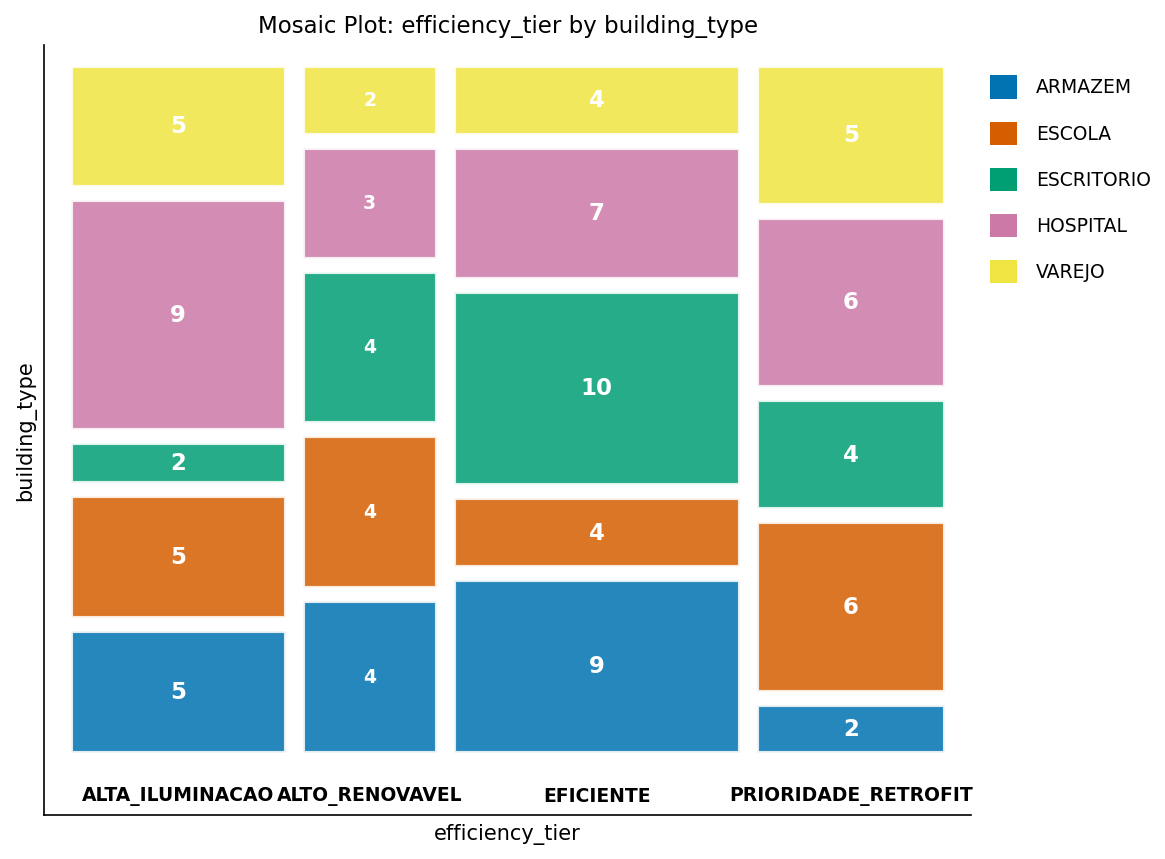

In [10]:
/* --------------------------------------------------------
   Perfila a solucao k=4 selecionada
   -------------------------------------------------------- */
DADOS work.bldg_profiled;
    MESCLAR work.building_metrics
          work.bldg_clust4 (MANTER=building_id CLUSTER distance);
    POR building_id;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=work.bldg_profiled mean std;
    CLASSE CLUSTER;
    VARIÁVEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    RÓTULO CLUSTER="Agrupamento"
          eui="EUI (kBtu/pe2/ano)"
          hvac_efficiency="Eficiencia do HVAC (COP)"
          envelope_r_value="Envelope (valor R)"
          lighting_wpf="Iluminacao (W/pe2)"
          renewable_pct="Percentual Renovavel (%)"
          building_age="Idade do Edificio (anos)";
    TÍTULO "Perfis de Nivel de Eficiencia de Edificios (k=4)";
EXECUTAR;

/* Rotula os niveis de eficiencia a partir dos centroides k=4 observados:
   Agrupamento 4 = melhor HVAC (3.89) com EUI baixo  -> EFICIENTE
   Agrupamento 2 = maior compensacao renovavel (28%) mas maior EUI -> ALTO_RENOVAVEL
   Agrupamento 3 = maior carga de iluminacao, HVAC fraco, EUI medio -> ALTA_ILUMINACAO
   Agrupamento 1 = EUI baixo mas HVAC mais fraco + envelope mais fino -> PRIORIDADE_RETROFIT */
DADOS work.bldg_tiered;
    DEFINIR work.bldg_profiled;
    COMPRIMENTO efficiency_tier $24;
    SE CLUSTER = 4 ENTÃO efficiency_tier = 'EFICIENTE';
    SENÃO SE CLUSTER = 2 ENTÃO efficiency_tier = 'ALTO_RENOVAVEL';
    SENÃO SE CLUSTER = 3 ENTÃO efficiency_tier = 'ALTA_ILUMINACAO';
    SENÃO SE CLUSTER = 1 ENTÃO efficiency_tier = 'PRIORIDADE_RETROFIT';
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    RÓTULO efficiency_tier="Nivel de Eficiencia" building_type="Tipo de Edificio";
    TÍTULO "Nivel de Eficiencia por Tipo de Edificio";
EXECUTAR;


---

### Interpretação

Com `REPLACE=FULL`, todos os valores de k convergiram de forma limpa. Nas quatro soluções, o R-quadrado geral aumentou monotonicamente com k — 0,305 (k=3), 0,410 (k=4), 0,459 (k=5), 0,515 (k=6) — enquanto a estatística pseudo-F atingiu o pico em **k=4 (22,23)** antes de declinar (20,13 em k=5, 19,93 em k=6). Combinado com um tamanho mínimo de agrupamento de 17 edifícios em k=4 (contra 13 em k=5 e 10 em k=6), a **solução k=4** oferece o melhor equilíbrio entre separação e estabilidade de níveis, por isso é perfilada abaixo.

Os quatro agrupamentos de k=4 mapeiam para perfis de eficiência claramente distintos (médias do perfil PROC MEANS acima):

- **Eficiente (Agrupamento 4, n=34):** o grupo mais bem equipado — maior eficiência de HVAC (COP 3,89) com EUI baixo-moderado de 72,4 kBtu/pé²/ano, com envelope adequado (R 18,8) e compensação renovável modesta (11,0%).
- **Alto renovável (Agrupamento 2, n=17):** os maiores consumidores absolutos (EUI 122,6), mas também de longe a maior compensação renovável (28,2%), com HVAC de faixa média (COP 3,42). Alta produção combinada com geração local.
- **Alta iluminação (Agrupamento 3, n=26):** EUI médio (94,0) impulsionado pela maior densidade de potência de iluminação (1,35 W/pé²) e pelo segundo HVAC mais fraco (COP 2,42), apesar do envelope mais espesso (R 19,6).
- **Prioridade de retrofit (Agrupamento 1, n=23):** EUI baixo no papel (63,8), mas o HVAC mais fraco (COP 2,28) e o envelope mais fino (R 12,5) — edifícios pequenos ou pouco usados, porém mal equipados, os candidatos mais claros para retrofits de envelope e HVAC.

A tabulação cruzada de nível por tipo de edifício mostra que escritórios (10) e armazéns (9) dominam o nível eficiente, enquanto hospitais se concentram no nível de alta iluminação (9 de 26). O nível de prioridade de retrofit está espalhado entre os tipos, liderado por hospitais e escolas (6 cada de 23). Para o desenho de programas, os 23 edifícios de prioridade de retrofit e os 26 de alta iluminação são os alvos naturais para incentivos de HVAC e iluminação respectivamente, enquanto os 17 edifícios de alto renovável — já gerando energia no local — são mais adequados para redução de demanda do que para incentivos adicionais de geração.


---

In [11]:
/* --------------------------------------------------------
   Exporta os niveis de eficiencia de edificios e os perfis de centroides
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
EXECUTAR;



NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>